# Return convergence across training seeds — one snapshot

Overlays the learning curves of the **differently seeded training runs of a single snapshot**,
so the seed spread behind the held-out results in
[`sps_eval_violins_seeds.ipynb`](sps_eval_violins_seeds.ipynb) can be read off directly.
Sibling of [`../3_gen_bat_cap_v1/sps_train_return_convergence.ipynb`](../3_gen_bat_cap_v1/sps_train_return_convergence.ipynb),
which overlays *different snapshots* instead — here every curve comes from the same frozen
code and trial config, and only `training_params.common.seed` differs.

Seed fan-outs are produced with the snapshot submitter's `--common-seed`:

```bash
python -m tools.snapshot.submit_snapshot --snapshot snapshots/<existing>/ --kind train --common-seed 46
```

which copies the frozen `configs/` into the run dir, rewrites `training_params.common.seed`
there and names the run `train_<timestamp>_cseed{N}`
(`tools/snapshot/submit_snapshot.py:454`, `:486`). The un-suffixed run is the snapshot's
original training run with the seed its frozen trial YAML declares.

**The seed of each run is read from that run's own `param_space.json`** (`"seed"` — the RLlib
algorithm config Ray was actually handed, written by `run_train_ray.py:179`), never from the
directory name: `common_model_setup` passes `training_config.seed` into `config.debugging(...)`
(`adv_building_gym/ray/training/common_model_config.py:205-208`), while the tune run directory
is named after the *top-level* `trial.seed` (`run_train_ray.py:360`) which `--common-seed`
leaves untouched — every run below therefore sits in a `ppo_seed42_*` directory regardless of
its actual learner seed.

For each run the main RLlib TBX log under `runs/train_*/models/**/events.out.tfevents.*` is
parsed (the `eval_trajectories/` sub-runs live under `ep_metrics/` and are not matched) and two
scalars are extracted:

| Series | Tag |
|---|---|
| training | `ray/tune/env_runners/episode_return_mean` |
| in-training eval | `ray/tune/evaluation/env_runners/episode_return_mean` |

> **Resumed runs:** a run restarted via `run_train_ray.py --restore` keeps writing into the
> *same* tune trial directory, so its curve is split over several event files with an overlap
> at the resume iteration. All event files of that directory are merged here (a step re-logged
> by a later file wins) — taking only the largest file, as the sibling notebook does, would
> silently truncate such a run.

> **Step axis:** the TBX step axis was switched from the tune iteration counter to
> `num_env_steps_sampled_lifetime` (commit `383a3e7`). Which one a snapshot used is detected
> per run by comparing its last logged step against `training_iteration` and
> `num_env_steps_sampled_lifetime` in the run's final `result_0.json`; `X_AXIS` then converts
> to episodes with that same result's `num_episodes_lifetime / training_iteration` ratio
> (the *measured* episodes-per-iteration, which exceeds `ppo.episodes_per_iteration` because
> RLlib overshoots the train batch to whole episodes across its EnvRunners).

Parsing an event file is slow, so extracted curves are cached as small CSVs under
`.tb_return_cache/` next to this notebook; delete that folder to force a re-parse.

**Main input:** set `SNAPSHOT_PATH` in the next cell.

In [53]:
# --- Main input ---------------------------------------------------------------------
# The single snapshot whose seeded training runs are overlaid (absolute, or relative to
# the repo root). Every runs/train_* directory below it becomes one curve.
ALGO_TYPE = "sac"
SNAPSHOT_PATH = "snapshots/20260703_004926_sta_lin_battery_only_price_sac"

# Restricts the picked-up run directories; "train_*" takes the original run plus every
# --common-seed fan-out. Set e.g. "train_*_cseed*" to drop the original.
RUN_GLOB = "train_*"

# The two RLlib return scalars, plotted as the training / eval series.
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# The training and eval per-seed figures are separate; SHARE_Y puts them on one common
# y-range so they stay comparable side by side in the thesis.
SHARE_Y = True

# x-axis unit: "episodes", "iterations" (the raw TBX step of these snapshots) or
# "env_steps" (millions). The conversion factors are read per run from result_0.json.
X_AXIS = "episodes"
EPISODE_LENGTH = 288  # env_meta.EPISODE_LENGTH of the trial; only used for env-step-indexed logs

# Spread drawn around the across-seed mean in the aggregate figure:
# "std" (± 1 standard deviation), "minmax" or "iqr" (25-75 %).
BAND = "std"

# Filename prefix for the saved figures.
OUT_PREFIX = f"{ALGO_TYPE}_seeds_return"

In [54]:
import hashlib
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
CACHE_DIR = NB_DIR / ".tb_return_cache"

snapshot_dir = Path(SNAPSHOT_PATH)
snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
if not snapshot_dir.is_dir():
    raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")


# Every event file of a run's main RLlib TBX log, oldest first. A resumed run
# (run_train_ray.py --restore) keeps writing into the same tune trial directory, so its
# curve is spread over several event files — all of them belong to the run. The trial
# directory with the largest total event bytes wins if a run somehow holds more than one.
def _training_event_files(run_dir: Path) -> list[Path]:
    candidates = list(run_dir.glob("models/**/events.out.tfevents.*"))
    if not candidates:
        raise FileNotFoundError(f"No training TBX event file under {run_dir / 'models'}")
    by_trial_dir: dict[Path, list[Path]] = {}
    for path in candidates:
        by_trial_dir.setdefault(path.parent, []).append(path)
    trial_dir = max(by_trial_dir, key=lambda directory: sum(p.stat().st_size for p in by_trial_dir[directory]))
    return sorted(by_trial_dir[trial_dir], key=lambda path: path.stat().st_mtime)


# Extracts the requested scalar tags from one run's event files into a long frame
# (tag, step, value), caching the result as a CSV keyed by every input file's
# path + size + mtime (so a resumed / extended run re-parses).
def _extract_curves(event_files: list[Path], tags: tuple[str, ...]) -> pd.DataFrame:
    fingerprint = "|".join(
        f"{path}:{path.stat().st_size}:{int(path.stat().st_mtime)}" for path in event_files
    ) + "|" + ",".join(sorted(tags))
    cache_path = CACHE_DIR / f"{hashlib.md5(fingerprint.encode()).hexdigest()}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    rows = []
    for file_order, event_file in enumerate(event_files):
        for event in EventFileLoader(str(event_file)).Load():
            for value in event.summary.value:
                if value.tag not in tags:
                    continue
                # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
                scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
                rows.append({"tag": value.tag, "step": event.step, "value": scalar, "file_order": file_order})
    if not rows:
        raise ValueError(f"None of {tags} found in {[str(p) for p in event_files]}")

    curves = (
        pd.DataFrame(rows)
        .sort_values(["tag", "file_order", "step"])
        # Resume overlap: the same step logged again by a later event file wins.
        .drop_duplicates(["tag", "step"], keep="last")
        .sort_values(["tag", "step"])
        .reset_index(drop=True)
    )
    CACHE_DIR.mkdir(exist_ok=True)
    curves.to_csv(cache_path, index=False)
    return curves


_CSEED_SUFFIX_REGEX = re.compile(r"_cseed(-?\d+)$")


# The learner seed Ray actually ran with: param_space.json is the algorithm config dump
# (run_train_ray.py:179) whose "seed" is training_params.common.seed. The _cseed{N} run-id
# suffix is only a fallback for runs whose param_space.json is missing.
def _run_seed(run_dir: Path) -> tuple[int | None, str]:
    param_space_path = run_dir / "param_space.json"
    if param_space_path.is_file():
        try:
            seed = json.loads(param_space_path.read_text()).get("seed")
        except (json.JSONDecodeError, OSError):
            seed = None
        if seed is not None:
            return int(seed), "param_space.json"
    match = _CSEED_SUFFIX_REGEX.search(run_dir.name)
    if match:
        return int(match.group(1)), "run-id suffix"
    return None, "unresolved"


# Step-axis unit and x-axis conversion factors, taken from the run's final tune result.
# Returns None when result_0.json is absent (killed / unfinished run) — the caller then
# falls back to the median of the runs that do have one.
def _run_step_scales(run_dir: Path, last_step: float) -> dict | None:
    result_path = run_dir / "result_0.json"
    if not result_path.is_file():
        return None
    try:
        metrics = json.loads(result_path.read_text())["metrics"]
    except (json.JSONDecodeError, OSError, KeyError):
        return None
    iterations = float(metrics["training_iteration"])
    env_steps = float(metrics["num_env_steps_sampled_lifetime"])
    episodes = float(metrics["env_runners"]["num_episodes_lifetime"])
    # Iteration-indexed vs env-step-indexed logs differ by ~3 orders of magnitude, so the
    # last logged step identifies the unit unambiguously.
    if abs(last_step - iterations) <= abs(last_step - env_steps):
        return {
            "step_unit": "iteration",
            "episodes_per_step": episodes / iterations,
            "env_steps_per_step": env_steps / iterations,
        }
    return {"step_unit": "env_step", "episodes_per_step": 1.0 / EPISODE_LENGTH, "env_steps_per_step": 1.0}


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float) -> np.ndarray:
    if weight <= 0.0:
        return np.asarray(values, dtype=float)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return np.asarray(smoothed, dtype=float)


print(f"Repo root: {REPO_ROOT}\nSnapshot : {snapshot_dir}\nCache dir: {CACHE_DIR}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Snapshot : /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/snapshots/20260703_004926_sta_lin_battery_only_price_sac
Cache dir: /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/.tb_return_cache


## Output naming

Everything saved here lands next to the notebook as
`<prefix>_<date>_<time>_out_<i>.<file format>`: one timestamp per notebook run, `out_index`
counting up per saved artefact, so no run overwrites an earlier one.

In [55]:
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    stem = f"{OUT_PREFIX}_{OUT_RUN_STAMP}_out_{out_index}"
    return OUT_DIR / f"{stem}.{file_format}"

## Load the per-seed curves

One record per `runs/train_*` directory: its seed, the number of merged event files, the
training and eval curves, and the step-axis scales. The table lists how far each seed ran and
where its returns ended up — `final_*` is the last **smoothed** value (`SMOOTHING`), which is
what the plots below show, while `max_eval` is the raw best in-training eval return.

A run whose `result_0.json` is missing (killed before the tuner wrote its final result) gets
the median scales of the other runs, with a note printed — its curve length is real, only the
episode/env-step conversion of its x-axis is borrowed.

In [56]:
run_dirs = sorted((snapshot_dir / "runs").glob(RUN_GLOB))
if not run_dirs:
    raise FileNotFoundError(f"No run directories matching '{RUN_GLOB}' under {snapshot_dir / 'runs'}")

records = []
for run_dir in run_dirs[1:]:
    if not run_dir.is_dir():
        continue
    seed, seed_source = _run_seed(run_dir)
    if seed is None:
        print(f"WARNING: no seed resolvable for {run_dir.name} — run skipped")
        continue
    event_files = _training_event_files(run_dir)
    curves = _extract_curves(event_files, (TRAIN_METRIC, EVAL_METRIC))
    series = {
        name: curves.loc[curves["tag"] == tag, ["step", "value"]].reset_index(drop=True)
        for name, tag in (("train", TRAIN_METRIC), ("eval", EVAL_METRIC))
    }
    missing = [name for name, frame in series.items() if frame.empty]
    if missing:
        raise ValueError(f"{run_dir.name}: no points for {missing} — check the metric tags")
    records.append({
        "run": run_dir.name,
        "seed": seed,
        "seed_source": seed_source,
        "event_files": len(event_files),
        "curves": series,
        "scales": _run_step_scales(run_dir, float(series["train"]["step"].iloc[-1])),
    })

if not records:
    raise FileNotFoundError(f"No usable runs matching '{RUN_GLOB}' under {snapshot_dir / 'runs'}")

seeds = [record["seed"] for record in records]
if len(seeds) != len(set(seeds)):
    raise ValueError(f"Two runs report the same seed ({seeds}) — the curves would be indistinguishable")
records.sort(key=lambda record: record["seed"])

# Runs without a final tune result inherit the median scales of the runs that have one.
resolved_scales = [record["scales"] for record in records if record["scales"] is not None]
if not resolved_scales:
    raise FileNotFoundError("No run has a result_0.json — the step-axis unit cannot be resolved")
step_units = {scale["step_unit"] for scale in resolved_scales}
if len(step_units) > 1:
    raise ValueError(f"Runs disagree on the TBX step unit ({step_units}) — plot them separately")
STEP_UNIT = step_units.pop()
median_scales = {
    "step_unit": STEP_UNIT,
    "episodes_per_step": float(np.median([scale["episodes_per_step"] for scale in resolved_scales])),
    "env_steps_per_step": float(np.median([scale["env_steps_per_step"] for scale in resolved_scales])),
}
for record in records:
    if record["scales"] is None:
        print(f"note: {record['run']} has no result_0.json — x-axis scales taken from the other runs")
        record["scales"] = median_scales

# One colour per seed; the aggregate figure uses the train/eval pair instead.
seed_palette = dict(zip([record["seed"] for record in records], sns.color_palette("colorblind", len(records))))
TRAIN_COLOR = "#0d54c4"  # strong blue
EVAL_COLOR = "#e2660a"   # strong orange

for record in records:
    for name in ("train", "eval"):
        record[f"smoothed_{name}"] = _tb_smooth(record["curves"][name]["value"].to_numpy(), SMOOTHING)

print(f"Step unit: {STEP_UNIT}  ({X_AXIS} on the x-axis)")
summary = pd.DataFrame([{
    "seed": record["seed"],
    "run": record["run"],
    "seed_from": record["seed_source"],
    "event_files": record["event_files"],
    "last_step": int(record["curves"]["train"]["step"].iloc[-1]),
    "episodes": int(record["curves"]["train"]["step"].iloc[-1] * record["scales"]["episodes_per_step"]),
    "train_points": len(record["curves"]["train"]),
    "eval_points": len(record["curves"]["eval"]),
    "final_train": round(float(record["smoothed_train"][-1]), 3),
    "final_eval": round(float(record["smoothed_eval"][-1]), 3),
    "max_eval": round(float(record["curves"]["eval"]["value"].max()), 3),
} for record in records]).set_index("seed")
summary

Step unit: iteration  (episodes on the x-axis)


,run,seed_from,event_files,last_step,episodes,train_points,eval_points,final_train,final_eval,max_eval
seed,,,,,,,,,,
42,train_20260801_160201_cseed42,param_space.json,1,1750,7000,1750,1741,12.290,12.926,16.631
46,train_20260731_184634_cseed46,param_space.json,1,1750,7000,1750,1741,13.323,13.353,17.136
71,train_20260731_184635_cseed71,param_space.json,1,1750,7000,1750,1741,12.830,13.014,16.710
97,train_20260801_160203_cseed97,param_space.json,1,1750,7000,1750,1741,12.707,13.183,16.579
141,train_20260731_184637_cseed141,param_space.json,1,1750,7000,1750,1741,12.549,13.146,16.622


## Per-seed curves

One line per seed, in **two standalone figures** — the training return and the in-training
eval return, each saved as its own `<prefix>_<date>_<time>_out_<i>.pdf` next to this notebook
and carrying **no title** (thesis-ready), so the series is named by the y-axis label. With
`SHARE_Y` both figures use one common y-range, keeping them comparable the way shared panels
would be. `plot_per_seed(..., y_min=..., y_max=...)` cuts that range for a single figure —
either bound alone is enough, the other side then stays where `SHARE_Y` (or matplotlib) put
it. Curves are smoothed with TensorBoard's debiased EWMA (`SMOOTHING`); the raw curve is
drawn faint behind each smoothed line while `SHOW_RAW` is set. The eval series is stepwise
because RLlib carries the last eval result forward between eval rounds
(`evaluation.interval = 10` iterations here).

As configured (the `sta_lin_battery_only_price` PPO snapshot, five seeds), all five runs rise
together and flatten out after roughly 3000 episodes at a smoothed **training** return of
11.03-11.96 — the seeds are nearly indistinguishable there. The **eval** figure separates them
much more: the four `--common-seed` reruns end at 12.19-12.86 while the snapshot's original
run (seed 42) sits about two return units lower throughout and ends at 10.27. Two runs are
also shorter than the rest: seed 46 stopped at 550 of 583 iterations (≈ 6612 episodes) and
seed 141 was resumed once, its curve merged from four event files.

In [57]:
sns.set_theme(style="whitegrid", context="notebook")

SERIES_LABELS = {"train": "Training return", "eval": "In-training eval return"}
# Each series gets its own standalone figure, so the y-label carries the series identity
# (the figures are untitled for the thesis).
Y_LABELS = {
    "train": "Training episode_return_mean",
    "eval": "In-training eval episode_return_mean",
}


# x values of one curve in the unit X_AXIS selects, using the run's own step scales.
def _x_values(record: dict, curve: pd.DataFrame) -> tuple[np.ndarray, str]:
    steps = curve["step"].to_numpy(dtype=float)
    scales = record["scales"]
    if X_AXIS == "episodes":
        return steps * scales["episodes_per_step"], "Training episodes"
    if X_AXIS == "iterations":
        if scales["step_unit"] != "iteration":
            return steps / scales["env_steps_per_step"], "Training iterations"
        return steps, "Training iterations"
    if X_AXIS == "env_steps":
        return steps * scales["env_steps_per_step"] / 1e6, "Environment steps (millions)"
    raise ValueError(f"X_AXIS must be 'episodes', 'iterations' or 'env_steps', got {X_AXIS!r}")


# Common y-limits over both series and every seed, computed from whatever is actually drawn
# (raw curves dominate the range when SHOW_RAW). Keeps the two standalone figures on the
# same scale, which separate figures otherwise lose.
def _shared_ylim(padding: float = 0.05) -> tuple[float, float] | None:
    if not SHARE_Y:
        return None
    drawn = [
        record["curves"][name]["value"].to_numpy() if SHOW_RAW else record[f"smoothed_{name}"]
        for record in records for name in ("train", "eval")
    ]
    lowest = min(float(values.min()) for values in drawn)
    highest = max(float(values.max()) for values in drawn)
    margin = padding * (highest - lowest)
    return lowest - margin, highest + margin


SHARED_YLIM = _shared_ylim()


# One standalone figure for `series_name` ("train" or "eval"), one line per seed.
#
# `y_min` / `y_max` optionally cut the y-axis for this figure alone, overriding SHARED_YLIM
# per side: pass only one to clip that end and leave the other at the shared / automatic
# limit (e.g. y_min=0 hides the early collapse while keeping the top as it was). Curves are
# clipped, not dropped — the data is untouched.
def plot_per_seed(series_name: str, y_min: float | None = None, y_max: float | None = None) -> None:
    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    x_label = ""
    for record in records:
        curve = record["curves"][series_name]
        x_values, x_label = _x_values(record, curve)
        color = seed_palette[record["seed"]]
        if SHOW_RAW:
            ax.plot(x_values, curve["value"], color=color, alpha=0.35, linewidth=0.5, zorder=1)
        ax.plot(x_values, record[f"smoothed_{series_name}"], color=color, linewidth=1.2,
                label=f"seed {record['seed']}", zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(Y_LABELS[series_name])
    ax.margins(x=0.01)
    if SHARED_YLIM is not None:
        ax.set_ylim(*SHARED_YLIM)
    # Applied last so an explicit bound wins over SHARED_YLIM; a None side keeps the limit
    # already in place (matplotlib leaves None-valued bounds unchanged).
    if y_min is not None or y_max is not None:
        ax.set_ylim(bottom=y_min, top=y_max)
    legend = ax.legend(title="", frameon=False, loc="lower right", handlelength=1.8)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}  ({SERIES_LABELS[series_name]})")
    plt.show()

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/sac_seeds_return_20260804_151112_out_1.pdf  (Training return)


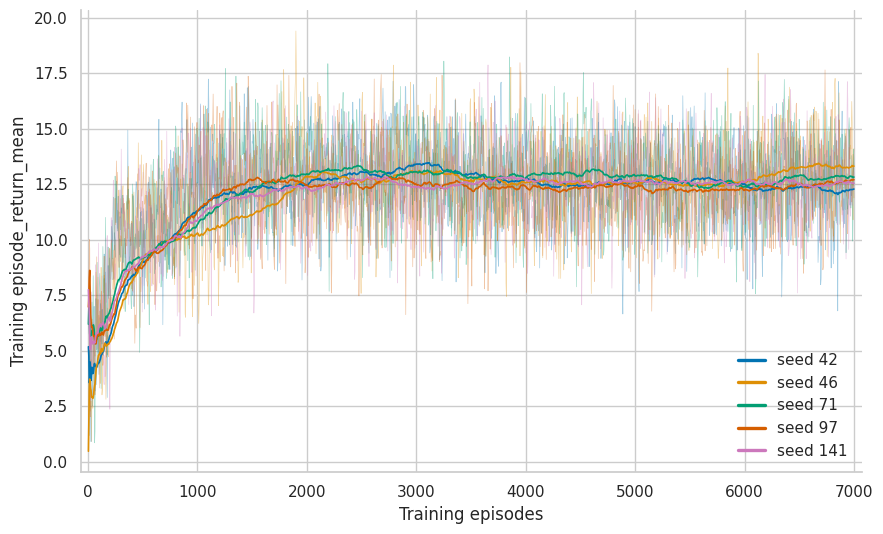

In [58]:
# Optional y-axis cut, per side: plot_per_seed("train", y_min=0.0, y_max=14.0)
plot_per_seed("train")

saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/sac_seeds_return_20260804_151112_out_4.pdf  (In-training eval return)


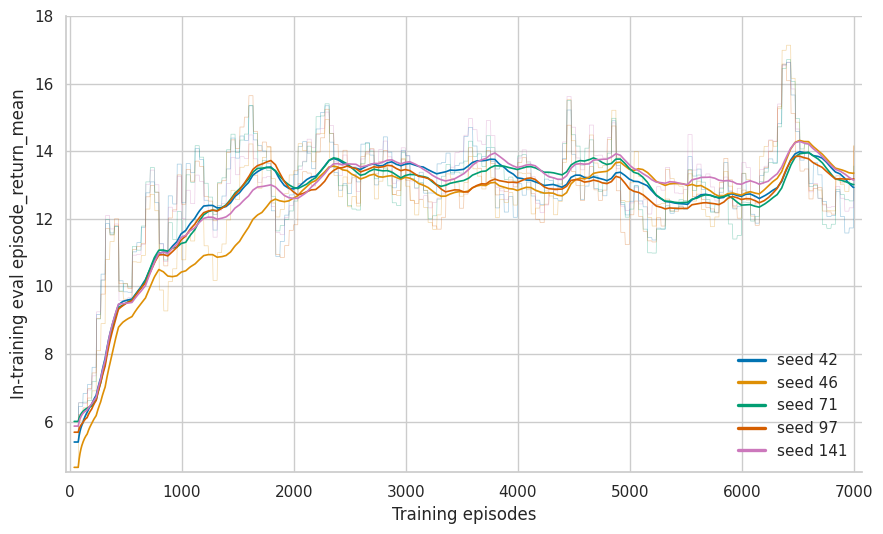

In [62]:
# Optional y-axis cut, per side: plot_per_seed("eval", y_min=0.0, y_max=14.0)
# plot_per_seed("eval")
plot_per_seed("eval", y_min=4.5, y_max=18.0)

## Across-seed mean and spread

The seed-wise smoothed curves are interpolated onto a common x-grid and reduced to a mean line
with a `BAND` spread, giving the training and eval curve of *the configuration* rather than of
any single run. Both series share this one figure — it exists to compare them — while the
per-seed detail lives in the two standalone figures above. The grid spans the range every seed
covers — from the largest first to the smallest last x value — so the band is computed from all
seeds everywhere; the printed range shows how much a short run clips off the end (here the grid
stops at 6612 episodes, the end of the shortest run).

Both means plateau after ≈ 3000 episodes and end within half a return unit of each other
(training 11.49, eval 11.91 at the grid end). The bands are what the figure is for: the eval
band is roughly three times as wide as the training one (± 1.03 vs ± 0.34 at the grid end), so
the eval-side seed differences seen in the per-seed figures are the dominant source of
variation, not the training return itself. The eval mean quoted here is slightly below the mean
of the `final_eval` column in the summary table because it is read at the common grid end
rather than at each run's own last point.

train: x 4-7000, final mean 12.740, final spread 12.356-13.124
 eval: x 40-7000, final mean 13.124, final spread 12.960-13.288
saved /home/iai/dj0397/AdvBuildingGym/thesis_eval/2_base_bat_rbc_vs_rl/sac_seeds_return_20260804_151112_out_3.pdf


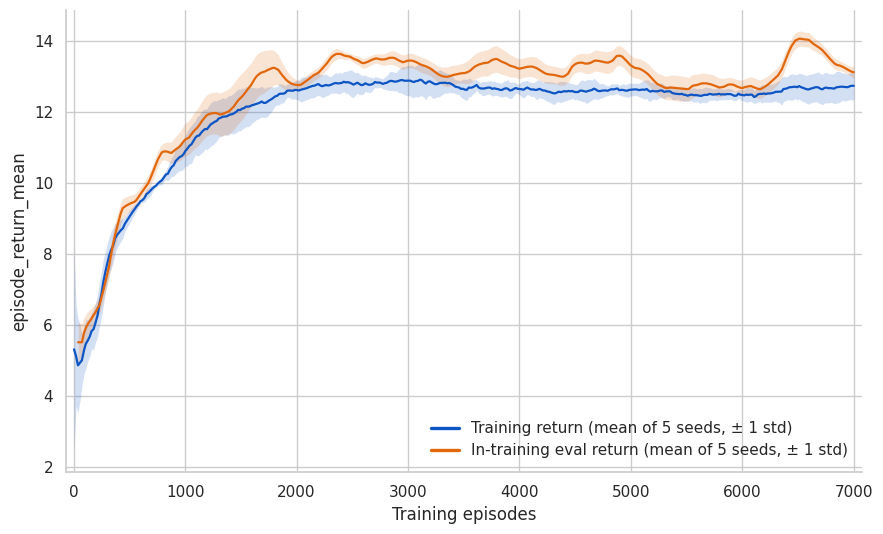

In [60]:
BAND_GRID_POINTS = 400


# Mean and spread of the per-seed smoothed curves on a shared x-grid.
def _aggregate(series_name: str) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, str]:
    x_per_seed, y_per_seed, x_label = [], [], ""
    for record in records:
        x_values, x_label = _x_values(record, record["curves"][series_name])
        x_per_seed.append(x_values)
        y_per_seed.append(record[f"smoothed_{series_name}"])

    grid_start = max(float(x_values[0]) for x_values in x_per_seed)
    grid_end = min(float(x_values[-1]) for x_values in x_per_seed)
    grid = np.linspace(grid_start, grid_end, BAND_GRID_POINTS)
    stacked = np.vstack([
        np.interp(grid, x_values, y_values) for x_values, y_values in zip(x_per_seed, y_per_seed)
    ])

    mean = stacked.mean(axis=0)
    if BAND == "std":
        deviation = stacked.std(axis=0, ddof=1) if len(stacked) > 1 else np.zeros_like(mean)
        lower, upper = mean - deviation, mean + deviation
    elif BAND == "minmax":
        lower, upper = stacked.min(axis=0), stacked.max(axis=0)
    elif BAND == "iqr":
        lower, upper = np.percentile(stacked, 25, axis=0), np.percentile(stacked, 75, axis=0)
    else:
        raise ValueError(f"BAND must be 'std', 'minmax' or 'iqr', got {BAND!r}")
    return grid, mean, lower, upper, x_label


BAND_LABELS = {"std": "± 1 std", "minmax": "min-max", "iqr": "IQR"}


def plot_seed_band() -> None:
    fig, ax = plt.subplots(figsize=(9.0, 5.5))
    x_label = ""
    for series_name, color in (("train", TRAIN_COLOR), ("eval", EVAL_COLOR)):
        grid, mean, lower, upper, x_label = _aggregate(series_name)
        ax.fill_between(grid, lower, upper, color=color, alpha=0.18, linewidth=0.0, zorder=1)
        ax.plot(grid, mean, color=color, linewidth=1.6,
                label=f"{SERIES_LABELS[series_name]} (mean of {len(records)} seeds, {BAND_LABELS[BAND]})", zorder=2)
        print(f"{series_name:>5}: x {grid[0]:.0f}-{grid[-1]:.0f}, final mean {mean[-1]:.3f}, "
              f"final spread {lower[-1]:.3f}-{upper[-1]:.3f}")

    ax.set_xlabel(x_label)
    ax.set_ylabel("episode_return_mean")
    ax.margins(x=0.01)
    legend = ax.legend(title="", frameon=False, loc="lower right", handlelength=1.8)
    for handle in legend.get_lines():
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path("pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"saved {pdf_path}")
    plt.show()


plot_seed_band()

## Seed spread of the converged return

`mean` / `std` / `min` / `max` across the per-seed end-of-training values from the summary
table: how much of the final return is seed noise rather than the configuration. `final_train`
and `final_eval` are smoothed (so they read the converged level, not the last noisy point),
`max_eval` is the raw best eval round each seed reached.

In [61]:
spread = summary[["final_train", "final_eval", "max_eval"]].agg(["mean", "std", "min", "max"]).round(3)
spread

,final_train,final_eval,max_eval
mean,12.740,13.124,16.736
std,0.383,0.164,0.229
min,12.290,12.926,16.579
max,13.323,13.353,17.136
